In [10]:
import os
import shutil
import hashlib
import random
import warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, UnidentifiedImageError
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

warnings.filterwarnings('ignore')


In [12]:
# CONFIGURATION
# ─────────────────────────────────────────────────────────────
DATASET_PATH   = r'D:\Files\AI X-Ray Detection\Dataset'
OUTPUT_PATH    = r'D:\Files\AI X-Ray Detection\Dataset_Cleaned'
QUARANTINE     = r'D:\Files\AI X-Ray Detection\Quarantine'
REPORTS_PATH   = r'D:\Files\AI X-Ray Detection\Reports'

SPLITS         = ['train', 'val', 'test']
CLASSES        = ['normal', 'pneumonia', 'tuberculosis']
VALID_EXTS     = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}
MIN_SIZE       = (64, 64)
HASH_THRESHOLD = 3          # perceptual hash distance for duplicate detection

# Augmentation targets — keeps classes balanced
# Set to 0 to skip augmentation for that split
AUG_TARGETS = {
    'train': 9000,   # safe — train has enough originals
    'val'  : 600,    # ← change to 600, not 1100
    'test' : 0       # never touch test
}

os.makedirs(QUARANTINE, exist_ok=True)
os.makedirs(REPORTS_PATH, exist_ok=True)

print("=" * 60)
print("  X-RAY PREPROCESSING PIPELINE")
print("=" * 60)

# ─────────────────────────────────────────────────────────────
#  STEP 1: DATASET AUDIT
# ─────────────────────────────────────────────────────────────
print("\n[STEP 1] Dataset Audit")
print("-" * 40)

def audit_dataset(base_path):
    audit = {}
    for split in SPLITS:
        split_path = os.path.join(base_path, split)
        if not os.path.exists(split_path):
            print(f"  ⚠️  Missing: {split_path}")
            continue
        audit[split] = {}
        for cls in CLASSES:
            cls_path = os.path.join(split_path, cls)
            if not os.path.isdir(cls_path):
                audit[split][cls] = 0
                continue
            files = [f for f in os.listdir(cls_path)
                     if Path(f).suffix.lower() in VALID_EXTS
                     and os.path.isfile(os.path.join(cls_path, f))]
            audit[split][cls] = len(files)
    return audit

audit = audit_dataset(DATASET_PATH)
total_all = 0

for split, classes in audit.items():
    split_total = sum(classes.values())
    total_all += split_total
    print(f"\n  [{split.upper()}]  —  {split_total} images")
    for cls, count in classes.items():
        bar = '█' * min(count // 20, 30)
        print(f"    {cls:<16} {count:>5}  {bar}")

print(f"\n  TOTAL: {total_all} images across all splits")

# Imbalance check
print("\n  Imbalance Analysis:")
for split, classes in audit.items():
    counts = list(classes.values())
    if max(counts) > 0 and min(counts) > 0:
        ratio = max(counts) / min(counts)
        flag = "⚠️  IMBALANCED" if ratio > 1.5 else "✅ Balanced"
        print(f"    [{split}] max/min ratio = {ratio:.2f}x  {flag}")

# Save audit to CSV
rows = []
for split, classes in audit.items():
    for cls, count in classes.items():
        rows.append({'split': split, 'class': cls, 'count': count})
pd.DataFrame(rows).to_csv(os.path.join(REPORTS_PATH, 'audit_before.csv'), index=False)

  X-RAY PREPROCESSING PIPELINE

[STEP 1] Dataset Audit
----------------------------------------

  [TRAIN]  —  13890 images
    normal            5090  ██████████████████████████████
    pneumonia         3668  ██████████████████████████████
    tuberculosis      5132  ██████████████████████████████

  [VAL]  —  1598 images
    normal             514  █████████████████████████
    pneumonia          540  ███████████████████████████
    tuberculosis       544  ███████████████████████████

  [TEST]  —  1489 images
    normal             513  █████████████████████████
    pneumonia          433  █████████████████████
    tuberculosis       543  ███████████████████████████

  TOTAL: 16977 images across all splits

  Imbalance Analysis:
    [train] max/min ratio = 1.40x  ✅ Balanced
    [val] max/min ratio = 1.06x  ✅ Balanced
    [test] max/min ratio = 1.25x  ✅ Balanced


In [13]:
def get_all_images(base_path):
    results = []
    for split in SPLITS:
        split_path = os.path.join(base_path, split)
        if not os.path.exists(split_path):
            continue
        for cls in CLASSES:
            cls_path = os.path.join(split_path, cls)
            if not os.path.isdir(cls_path):
                continue
            for fname in os.listdir(cls_path):
                if Path(fname).suffix.lower() in VALID_EXTS:
                    fpath = os.path.join(cls_path, fname)
                    if os.path.isfile(fpath):
                        results.append((fpath, split, cls))
    return results

all_images    = get_all_images(DATASET_PATH)
corrupt_files = []
too_small     = []
clean_files   = []

for fpath, split, cls in tqdm(all_images, desc="Validating"):
    try:
        with Image.open(fpath) as img:
            img.verify()
        with Image.open(fpath) as img:
            w, h = img.size
            if w < MIN_SIZE[0] or h < MIN_SIZE[1]:
                too_small.append((fpath, split, cls, w, h))
            else:
                clean_files.append((fpath, split, cls))
    except Exception as e:
        corrupt_files.append((fpath, split, cls, str(e)))

print(f"✅ Clean     : {len(clean_files)}")
print(f"❌ Corrupt   : {len(corrupt_files)}")
print(f"⚠️  Too small : {len(too_small)}")

Validating: 100%|██████████| 16977/16977 [01:13<00:00, 230.69it/s] 

✅ Clean     : 16977
❌ Corrupt   : 0
⚠️  Too small : 0


In [14]:
def quarantine_file(fpath, reason):
    dest_dir = os.path.join(QUARANTINE, reason)
    os.makedirs(dest_dir, exist_ok=True)
    fname = os.path.basename(fpath)
    dest  = os.path.join(dest_dir, fname)
    if os.path.exists(dest):
        base, ext = os.path.splitext(fname)
        dest = os.path.join(dest_dir,
               f"{base}_{hashlib.md5(fpath.encode()).hexdigest()[:6]}{ext}")
    try:
        shutil.move(fpath, dest)
    except Exception as e:
        print(f"Could not move {fname}: {e}")

moved = 0
for fpath, split, cls, _ in corrupt_files:
    quarantine_file(fpath, 'corrupt')
    moved += 1
for fpath, split, cls, w, h in too_small:
    quarantine_file(fpath, 'too_small')
    moved += 1

print(f"🗂️  Moved {moved} files to quarantine")
print(f"   Folder: {QUARANTINE}")
print(f"   (Files NOT deleted — recoverable if needed)")

🗂️  Moved 0 files to quarantine
   Folder: D:\Files\AI X-Ray Detection\Quarantine
   (Files NOT deleted — recoverable if needed)


In [20]:
import os
from pathlib import Path
from collections import Counter

RESTORE_FOLDER = r'D:\Files\AI X-Ray Detection\Quarantine\restored'

files = [f for f in os.listdir(RESTORE_FOLDER)
         if Path(f).suffix.lower() in {'.jpg','.jpeg','.png','.bmp'}]

print(f'Total files to restore: {len(files)}')
print(f'\nSample filenames:')
for f in files[:20]:
    print(f'  {f}')

Total files to restore: 10268

Sample filenames:
  IM-0001-0001.jpg
  IM-0003-0001.jpg
  IM-0005-0001.jpg
  IM-0006-0001.jpg
  IM-0007-0001.jpg
  IM-0009-0001.jpg
  IM-0010-0001.jpg
  IM-0011-0001-0001.jpg
  IM-0011-0001-0002.jpg
  IM-0011-0001.jpg
  IM-0013-0001.jpg
  IM-0015-0001.jpg
  IM-0016-0001.jpg
  IM-0017-0001.jpg
  IM-0019-0001.jpg
  IM-0021-0001.jpg
  IM-0022-0001.jpg
  IM-0023-0001.jpg
  IM-0025-0001.jpg
  IM-0027-0001.jpg


In [18]:
import os
from pathlib import Path

QUARANTINE = r'D:\Files\AI X-Ray Detection\Quarantine\duplicates'

files = [f for f in os.listdir(QUARANTINE)
         if Path(f).suffix.lower() in {'.jpg','.jpeg','.png','.bmp'}]

print(f'Total quarantined: {len(files)}')
print(f'Sample files:')
for f in files[:10]:
    print(f'  {f}')

Total quarantined: 10268
Sample files:
  IM-0001-0001.jpg
  IM-0003-0001.jpg
  IM-0005-0001.jpg
  IM-0006-0001.jpg
  IM-0007-0001.jpg
  IM-0009-0001.jpg
  IM-0010-0001.jpg
  IM-0011-0001-0001.jpg
  IM-0011-0001-0002.jpg
  IM-0011-0001.jpg


In [22]:
import hashlib
from collections import defaultdict
from tqdm import tqdm

print("Duplicate Detection (MD5 — exact files only)")
print("-" * 40)

current_images = get_all_images(DATASET_PATH)
md5_groups     = defaultdict(list)

for fpath, split, cls in tqdm(current_images, desc="Computing MD5"):
    try:
        with open(fpath, 'rb') as f:
            md5 = hashlib.md5(f.read()).hexdigest()
        md5_groups[md5].append(fpath)
    except Exception:
        pass

dup_groups  = {k: v for k, v in md5_groups.items() if len(v) > 1}
total_dupes = sum(len(v) - 1 for v in dup_groups.values())

print(f"Exact duplicate groups : {len(dup_groups)}")
print(f"Files to remove        : {total_dupes}")

removed = 0
for md5, paths in dup_groups.items():
    for dupe in paths[1:]:
        quarantine_file(dupe, 'exact_duplicates')
        removed += 1

print(f"✅ Removed {removed} exact duplicates")

Duplicate Detection (MD5 — exact files only)
----------------------------------------


Computing MD5: 100%|██████████| 16912/16912 [01:08<00:00, 248.48it/s] 

Exact duplicate groups : 140
Files to remove        : 140
✅ Removed 140 exact duplicates


In [23]:
current_images = get_all_images(DATASET_PATH)
converted = 0

for fpath, split, cls in tqdm(current_images, desc="Converting to RGB"):
    try:
        with Image.open(fpath) as img:
            changed = False
            if img.mode == 'RGBA':
                img = img.convert('RGB'); changed = True
            elif img.mode == 'P':
                img = img.convert('RGB'); changed = True
            elif img.mode == 'L':
                img = img.convert('RGB'); changed = True
            elif img.mode in ('I', 'F'):
                arr = np.array(img, dtype=np.float32)
                arr = ((arr - arr.min()) / (arr.max() - arr.min() + 1e-9) * 255).astype(np.uint8)
                img = Image.fromarray(arr).convert('RGB')
                changed = True

            if changed:
                save_path = os.path.splitext(fpath)[0] + '.jpg'
                img.save(save_path, 'JPEG', quality=95)
                if save_path != fpath and os.path.exists(fpath):
                    os.remove(fpath)
                converted += 1
    except Exception as e:
        quarantine_file(fpath, 'conversion_errors')

print(f"✅ Converted {converted} images to RGB")

Converting to RGB: 100%|██████████| 16772/16772 [00:36<00:00, 463.87it/s] 

✅ Converted 0 images to RGB


✅ Chart saved → D:\Files\AI X-Ray Detection\Reports\distribution_clean.png


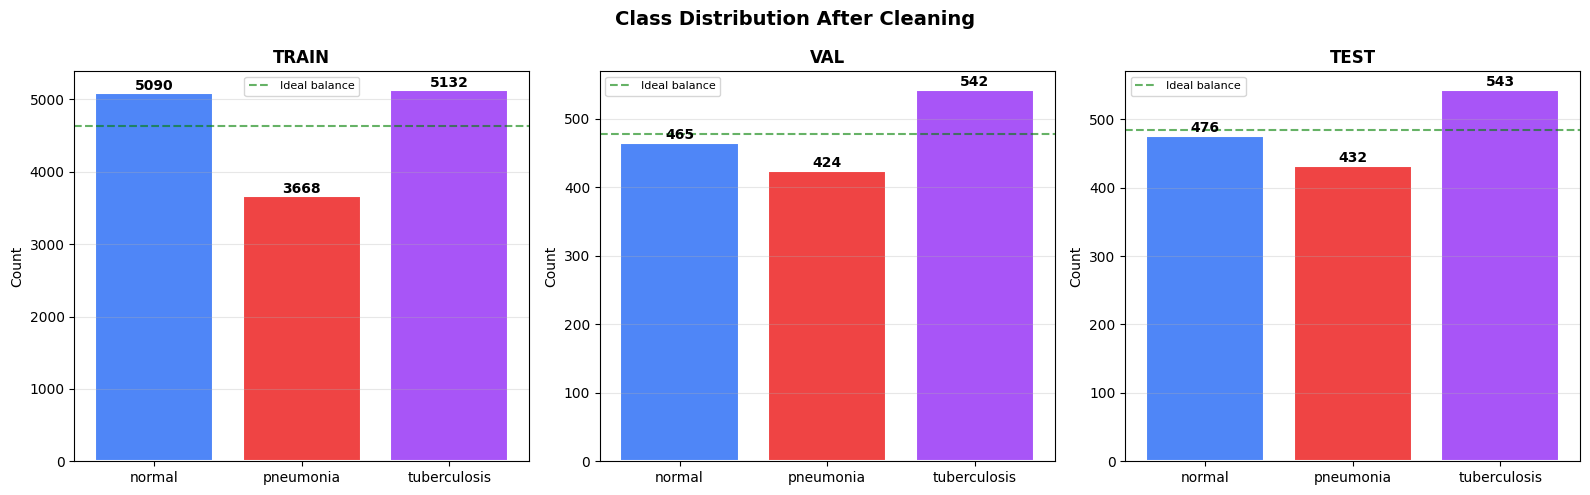

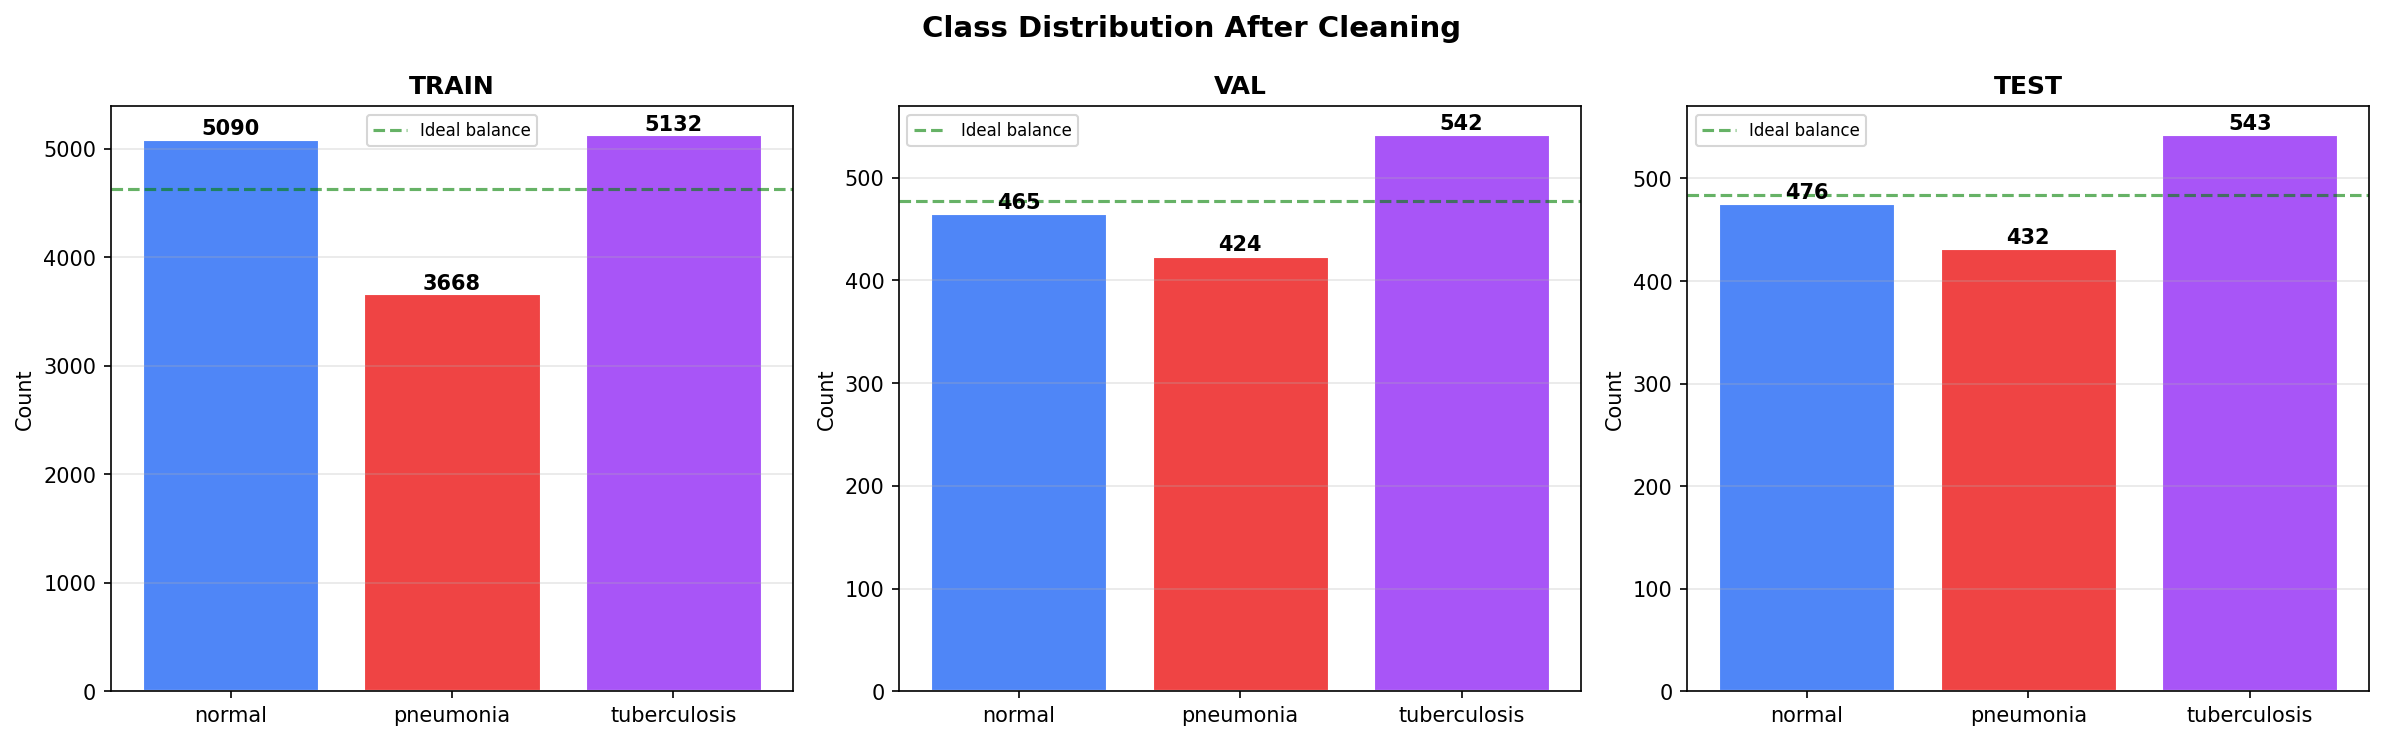

In [27]:
%matplotlib inline
plt.close('all')

# Create Reports folder if it doesn't exist
os.makedirs(REPORTS_PATH, exist_ok=True)

audit_clean = audit_dataset(DATASET_PATH)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Class Distribution After Cleaning', fontsize=14, fontweight='bold')
colors = ['#4f86f7', '#ef4444', '#a855f7']

for ax, (split, classes) in zip(axes, audit_clean.items()):
    names  = list(classes.keys())
    counts = list(classes.values())
    bars   = ax.bar(names, counts, color=colors[:len(names)],
                    edgecolor='white', linewidth=1.5)
    ax.set_title(split.upper(), fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2.,
                bar.get_height() + 1, str(count),
                ha='center', va='bottom', fontweight='bold')
    if sum(counts) > 0:
        ideal = sum(counts) / len(counts)
        ax.axhline(y=ideal, color='green', linestyle='--',
                   alpha=0.6, label='Ideal balance')
        ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

save_path = os.path.join(REPORTS_PATH, 'distribution_clean.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"✅ Chart saved → {save_path}")
plt.show()

from IPython.display import Image as IPImage, display
display(IPImage(filename=save_path))

In [28]:
import albumentations as A

train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=12, p=0.7),
    A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.1, rotate_limit=10, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.18, contrast_limit=0.18, p=0.6),
    A.GaussNoise(var_limit=(10, 40), p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8), p=0.4),
    A.GridDistortion(num_steps=5, distort_limit=0.15, p=0.25),
    A.Sharpen(alpha=(0.1, 0.4), lightness=(0.5, 1.0), p=0.3),
])

val_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=8, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.12, contrast_limit=0.12, p=0.4),
    A.CLAHE(clip_limit=2.0, p=0.3),
])

def augment_class(src_cls_path, dst_cls_path, target_count, pipeline):
    os.makedirs(dst_cls_path, exist_ok=True)
    src_files = [f for f in os.listdir(src_cls_path)
                 if Path(f).suffix.lower() in VALID_EXTS
                 and os.path.isfile(os.path.join(src_cls_path, f))]
    if not src_files:
        print(f"  ⚠️  No source files in {src_cls_path}")
        return 0

    for fname in src_files:
        dst = os.path.join(dst_cls_path, fname)
        if not os.path.exists(dst):
            shutil.copy2(os.path.join(src_cls_path, fname), dst)

    existing = len([f for f in os.listdir(dst_cls_path)
                    if Path(f).suffix.lower() in VALID_EXTS])
    needed   = max(0, target_count - existing)

    if needed == 0:
        print(f"  Already {existing} images — skipping")
        return 0

    aug_idx = 0
    pbar    = tqdm(total=needed, desc=f"  Augmenting", leave=False)

    while aug_idx < needed:
        fname = random.choice(src_files)
        fpath = os.path.join(src_cls_path, fname)
        try:
            image = cv2.imread(fpath)
            if image is None: continue
            image     = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            augmented = pipeline(image=image)['image']
            base      = os.path.splitext(fname)[0]
            save_name = f"{base}_aug_{aug_idx:05d}.jpg"
            save_path = os.path.join(dst_cls_path, save_name)
            cv2.imwrite(save_path,
                        cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR),
                        [cv2.IMWRITE_JPEG_QUALITY, 95])
            aug_idx += 1
            pbar.update(1)
        except Exception:
            pass

    pbar.close()
    return aug_idx

print("✅ Augmentation pipeline ready")

✅ Augmentation pipeline ready


In [29]:
for split, target in AUG_TARGETS.items():
    src_split = os.path.join(DATASET_PATH, split)
    dst_split = os.path.join(OUTPUT_PATH,  split)

    if not os.path.exists(src_split):
        print(f"⚠️  {split} folder not found — skipping")
        continue

    if split == 'test':
        print(f"\nCopying test (no augmentation)...")
        if os.path.exists(dst_split):
            shutil.rmtree(dst_split)
        shutil.copytree(src_split, dst_split)
        print(f"✅ Test copied")
        continue

    pipeline = train_aug if split == 'train' else val_aug
    print(f"\n[{split.upper()}] target = {target} per class")

    for cls in CLASSES:
        src_cls = os.path.join(src_split, cls)
        dst_cls = os.path.join(dst_split, cls)
        if not os.path.isdir(src_cls):
            print(f"  ⚠️  {cls} missing")
            continue
        print(f"  Class: {cls}")
        n_aug = augment_class(src_cls, dst_cls, target, pipeline)
        final = len([f for f in os.listdir(dst_cls)
                     if Path(f).suffix.lower() in VALID_EXTS])
        print(f"  Generated {n_aug} aug images → {final} total")

print(f"\n✅ Augmentation done → {OUTPUT_PATH}")


[TRAIN] target = 9000 per class
  Class: normal


  Generated 3910 aug images → 9000 total
  Class: pneumonia


  Generated 5332 aug images → 9000 total
  Class: tuberculosis


  Generated 3868 aug images → 9000 total

[VAL] target = 600 per class
  Class: normal


  Generated 135 aug images → 600 total
  Class: pneumonia


  Generated 176 aug images → 600 total
  Class: tuberculosis


  Generated 58 aug images → 600 total

Copying test (no augmentation)...
✅ Test copied

✅ Augmentation done → D:\Files\AI X-Ray Detection\Dataset_Cleaned


In [30]:
def print_summary(base_path, label):
    audit = audit_dataset(base_path)
    print(f"\n{label}")
    print(f"{'Split':<10} {'Class':<18} {'Count':>8}")
    print("-" * 38)
    grand = 0
    for split, classes in audit.items():
        for cls, count in classes.items():
            print(f"{split:<10} {cls:<18} {count:>8}")
            grand += count
        print("-" * 38)
    print(f"{'TOTAL':<28} {grand:>8}")

print_summary(DATASET_PATH, "ORIGINAL (Cleaned)")
print_summary(OUTPUT_PATH,  "AUGMENTED OUTPUT")

print(f"\n🎉 Preprocessing Complete!")
print(f"   Use this path for training:")
print(f"   {OUTPUT_PATH}")


ORIGINAL (Cleaned)
Split      Class                 Count
--------------------------------------
train      normal                 5090
train      pneumonia              3668
train      tuberculosis           5132
--------------------------------------
val        normal                  465
val        pneumonia               424
val        tuberculosis            542
--------------------------------------
test       normal                  476
test       pneumonia               432
test       tuberculosis            543
--------------------------------------
TOTAL                           16772

AUGMENTED OUTPUT
Split      Class                 Count
--------------------------------------
train      normal                 9000
train      pneumonia              9000
train      tuberculosis           9000
--------------------------------------
val        normal                  600
val        pneumonia               600
val        tuberculosis            600
---------------------------